#Mango Leaf Classification
###Thành viên:
  + Lê Văn Hoàng - 22520465 (C)
  + Thái Đình Nhật Hiển - 22520424<br>

###Thông tin đồ án:
+ <b>Tên đề tài:</b> Phân loại lá xoài bình thường và lá xoài bị sâu bệnh
+ <b>Tập dữ liệu:</b> Gồm 500 ảnh lá xoài bình thường và 2000 ảnh cho lá xoài bị sâu bệnh, mỗi loại sâu bệnh gồm 500 ảnh.
+ <b>Thư viện sử dụng:</b> cv2, matplotlib, skimage, sklearn, numpy
+ <b>Đặc trưng sử dụng:</b> Sobel, Histogram, kết hợp hai đặc trưng
+ <b>Mô hình máy học sử dụng:</b> KNN, SVC
+ <b>Phương thức đánh giá sử dụng:</b> Accuracy, F1-Score, Confusion Matrix

# Import Library

In [ ]:
import numpy as np
import os
import matplotlib.pyplot as plt
import cv2
import joblib
from google.colab.patches import cv2_imshow
from skimage.io import imread
from skimage.transform import resize
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report,f1_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,f1_score
from sklearn.metrics import roc_curve, auc
from google.colab.patches import cv2_imshow
from joblib import Parallel, delayed




# Clone Github

In [ ]:
!git clone https://github.com/NhatHienUIT/MangoLeaf.git /content/MangoLeaf

Cloning into '/content/MangoLeaf'...
remote: Enumerating objects: 2547, done.
remote: Counting objects: 100% (39/39), done.
remote: Compressing objects: 100% (36/36), done.
remote: Total 2547 (delta 9), reused 0 (delta 0), pack-reused 2508 (from 1)
Receiving objects: 100% (2547/2547), 67.77 MiB | 31.77 MiB/s, done.
Resolving deltas: 100% (183/183), done.


 # Tập dữ liệu:
 + Tập dữ liệu: Gồm 500 ảnh lá xoài bình thường và 2000 ảnh cho lá xoài bị sâu bệnh, mỗi loại sâu bệnh gồm 500 ảnh.
 + Tình trạng lá xoài bao gồm: Khỏe mạnh,nấm mốc bột, nấm đen, vết loét do vi khuẩn, ruồi cuốn lá

Loading category: Khỏe mạnh


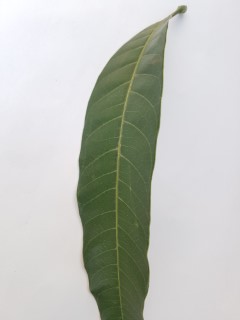

Loading category: Nấm mốc bột


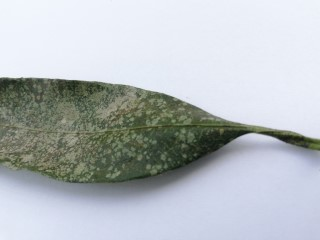

Loading category: Nấm đen


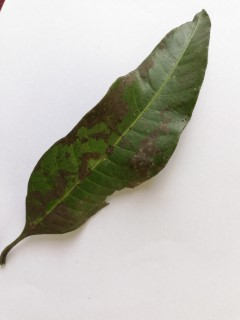

Loading category: Vết loét


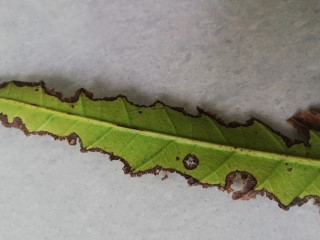

Loading category: Ruồi cuốn lá


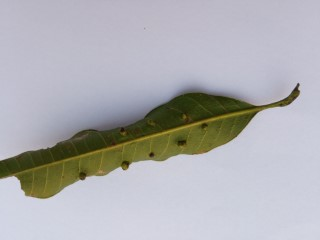

In [ ]:
input_dir = "/content/MangoLeaf/final_project"
categories = ['Khỏe mạnh','Nấm mốc bột','Nấm đen','Vết loét','Ruồi cuốn lá']
images = []

for category in categories:
  print(f"Loading category: {category}")
  path = os.path.join(input_dir,category)
  for img in os.listdir(path):
    img_path = os.path.join(path,img)
    img = cv2.imread(img_path)
    cv2_imshow(img)

    break


# Tiền xử lý dữ liệu

In [ ]:
input_dir = "/content/MangoLeaf/final_project"
categories = ['Khỏe mạnh','Nấm mốc bột','Nấm đen','Vết loét','Ruồi cuốn lá']

data = []
labels = []
datas = []
labelss = []
for idx,category in enumerate(categories):
  print(f"Loading image from category: {category}")
  if category != 'Khỏe mạnh' :
    idx = 1
  class_dir = os.path.join(input_dir,category)
  for img_name in os.listdir(class_dir) :
    img_dir = os.path.join(class_dir,img_name)
    img = cv2.imread(img_dir)
    datas.append(img)
    labelss.append(idx)
    img = cv2.resize(img,(64,64)) ## fix here
    data.append(img)
    labels.append(idx)
data = np.asarray(data)
labels = np.asarray(labels)
# data_train, data_test, y_train, y_test = train_test_split(datas, labelss, test_size=0.3, random_state=28)


Loading image from category: Khỏe mạnh
Loading image from category: Nấm mốc bột
Loading image from category: Nấm đen
Loading image from category: Vết loét
Loading image from category: Ruồi cuốn lá


# Hàm hiển thị ảnh được phân loại đúng và sai

In [ ]:
def plot_classification_results(data_test, y_test, y_pred, images=None):
    correct_indices = np.where(y_pred == y_test)[0]
    incorrect_indices = np.where(y_pred != y_test)[0]

    display_images(data_test, y_test, y_pred,correct_indices, "Ảnh phân loại đúng", 4)
    display_images(data_test, y_test, y_pred,incorrect_indices, "Ảnh phân loại sai", 2)


In [ ]:
def display_images(data_test,y_test, y_pred, indices, title, n):
    if len(indices) < n:
        n = len(indices)
    plt.figure(figsize=(25, 5))
    true_vals = []
    pred = []
    for idx, i in enumerate(y_test):
        if i == 1:
          true_vals.append("Bị sâu bệnh")
        else:
          true_vals.append("Khỏe mạnh")
    for idx, i in enumerate(y_pred):
        if i == 1:
          pred.append("Bị sâu bệnh")
        else:
          pred.append("Khỏe mạnh")
    for i, idx in enumerate(indices[:n]):
        plt.subplot(1, n, i + 1)
        plt.imshow(data_test[idx])
        plt.title(f"Phân loại: {pred[idx]}\nLớp thực: {true_vals[idx]}")
        plt.axis('off')
    plt.suptitle(title)
    plt.show()


# Trích xuất đặc trưng bằng Sobel

In [ ]:
def sobel_filter(img) :
  Sx = np.array([[-1,0,1],[-2,0,2],[-1,0,1]])
  Sy = np.array([[1,2,1],[0,0,0],[-1,-2,-1]])
  #Sx_ = np.array([[1,0,-1],[2,0,-2],[1,0,-1]])
 # Sy_ = np.array([[-1,-2,-1],[0,0,0],[1,2,1]])
  Ix = cv2.filter2D(img,-1,Sx)
  Iy = cv2.filter2D(img,-1,Sy)
  G = np.sqrt(Ix**2 + Iy**2)
  G = G/(G.max()+1e-7) *255
  return Ix,Iy,G

In [ ]:
def feature_sobel(img) :
  h,w,c = img.shape
  G = np.zeros((h,w))
  for i in range(c) :
    img_c = img[:,:,i]
    img_c = img_c.astype(float)
    _,_,g = sobel_filter(img_c)
    G += g
  row_sum = np.sum(G,axis=1,dtype = np.float64)
  col_sum = np.sum(G,axis=0,dtype=np.float64)
  return (np.hstack((row_sum.T,col_sum)))

#### Visualize hình ảnh sau khi trích xuất đặc trưng Sobel

Loading image with sobel feature from category: Khỏe mạnh


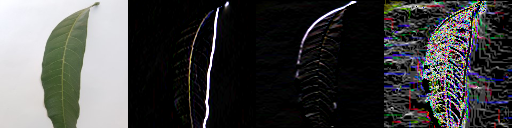

Loading image with sobel feature from category: Nấm mốc bột


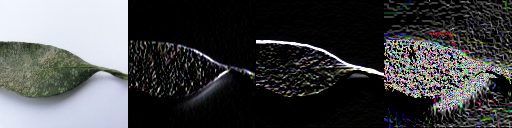

Loading image with sobel feature from category: Nấm đen


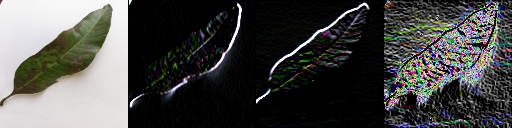

Loading image with sobel feature from category: Vết loét


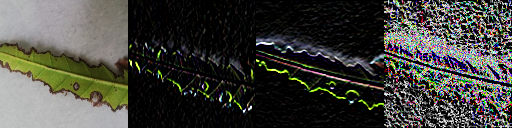

Loading image with sobel feature from category: Ruồi cuốn lá


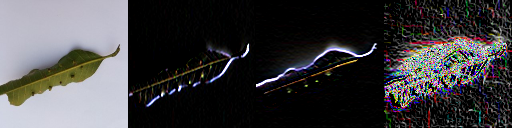

In [ ]:
for idx,category in enumerate(categories):
  print(f"Loading image with sobel feature from category: {category}")
  class_dir = os.path.join(input_dir,category)
  for img_name in os.listdir(class_dir):
    img_dir = os.path.join(class_dir,img_name)
    img = cv2.imread(img_dir)
    img = cv2.resize(img,(128,128))
    img1,img2,img3 = sobel_filter(img)
    horizontal_concat = np.concatenate((img, img1, img2,img3), axis=1)
    cv2_imshow(horizontal_concat)

    break


#### Trích xuất đặc trưng và chia tập dữ liệu

In [ ]:
#X = [feature_sobel(i) for i in data]
#X = np.asarray(X)
data_train,data_test,y_train,y_test = train_test_split(data,labels,test_size=0.3,random_state=28)
X_train = [feature_sobel(i) for i in data_train]
X_train = np.asarray(X_train)
X_test = [feature_sobel(i) for i in data_test]
X_test = np.asarray(X_test)

####KNN Model

Fitting 5 folds for each of 234 candidates, totalling 1170 fits
Best Parameters: {'metric': 'cosine', 'n_neighbors': 8, 'weights': 'distance'}
Test Accuracy Score: 0.8106666666666666
F1 Score (weighted): 0.8507179487179487
Confusion Matrix:
 [[ 29  21]
 [121 579]]


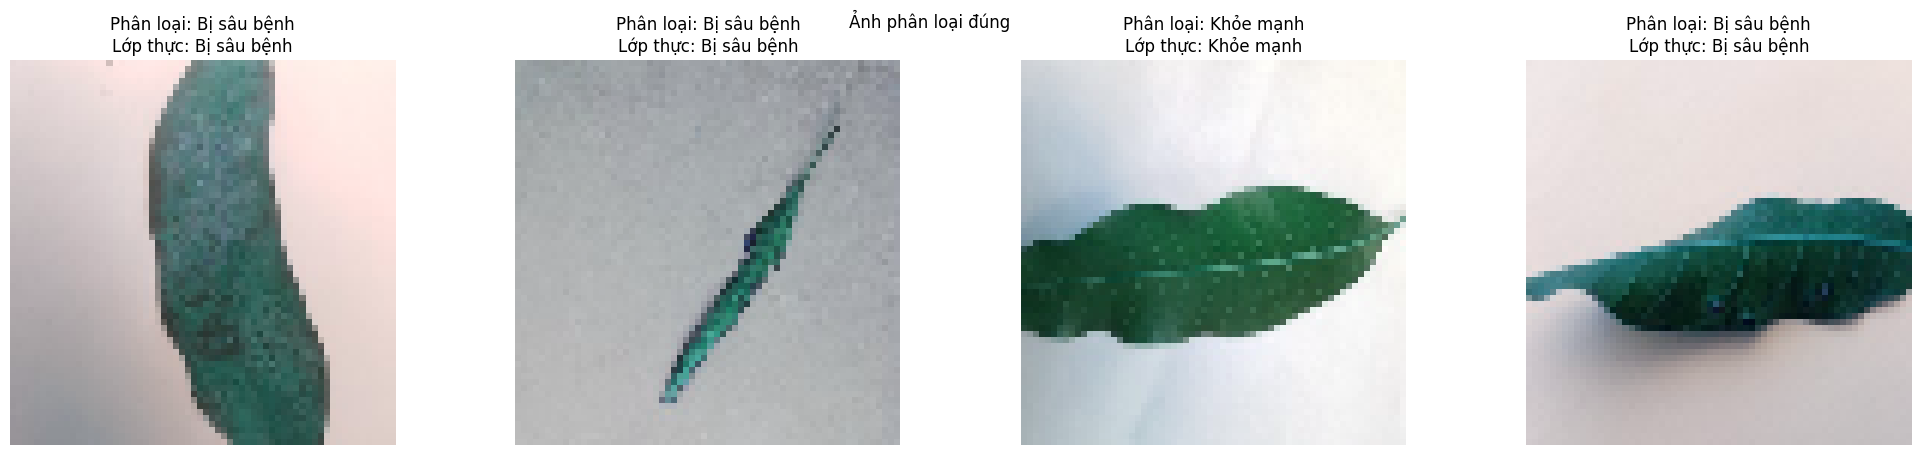

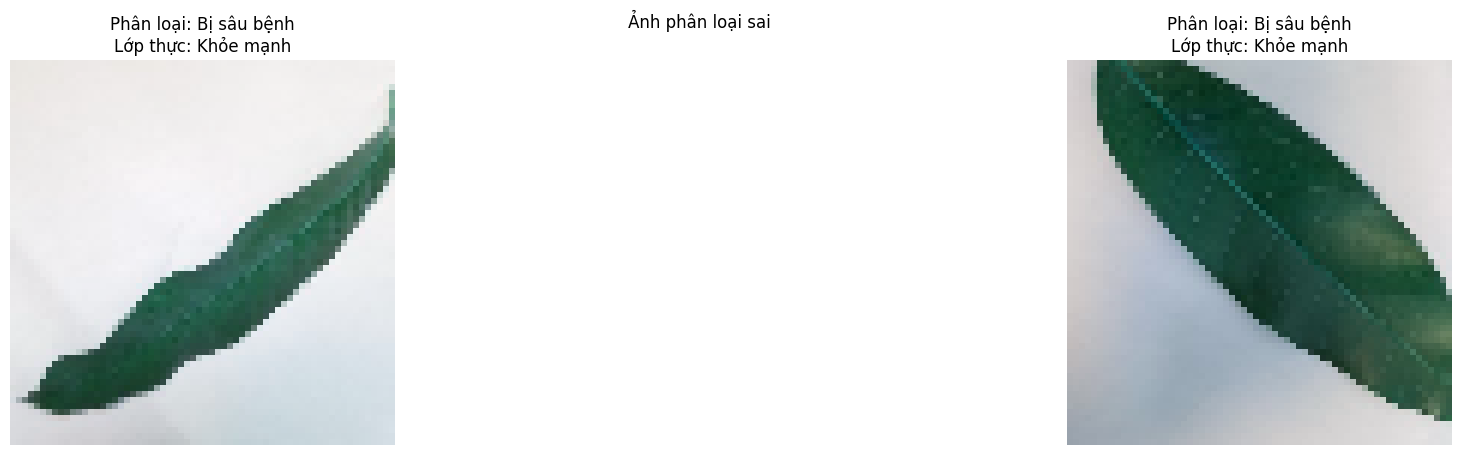

['sob_knn.pkl']

In [ ]:
param_grid = {'n_neighbors' : np.arange(1,40,1), 'weights' : ['uniform','distance'], 'metric' : ['cosine','euclidean','minkowski']}
sob_knn = GridSearchCV(KNeighborsClassifier(),param_grid,cv=5,scoring = 'f1',verbose=1)
sob_knn.fit(X_train,y_train)
print("Best Parameters:", sob_knn.best_params_)
y_pred = sob_knn.predict(X_test)
print("Test Accuracy Score:", accuracy_score(y_pred, y_test))
print("F1 Score (weighted):", f1_score(y_pred, y_test, average='weighted'))
print("Confusion Matrix:\n", confusion_matrix(y_pred, y_test))
plot_classification_results(data_test, y_test, y_pred)
# Save the model as a pickle in a file
joblib.dump(sob_knn, 'sob_knn.pkl')

####SVC Model

Fitting 5 folds for each of 98 candidates, totalling 490 fits
Best Parameters: {'C': 1.9000000000000001, 'kernel': 'rbf'}
Test Accuracy Score: 0.8306666666666667
F1 Score (weighted): 0.8585390160769765
Confusion Matrix:
 [[ 44  21]
 [106 579]]


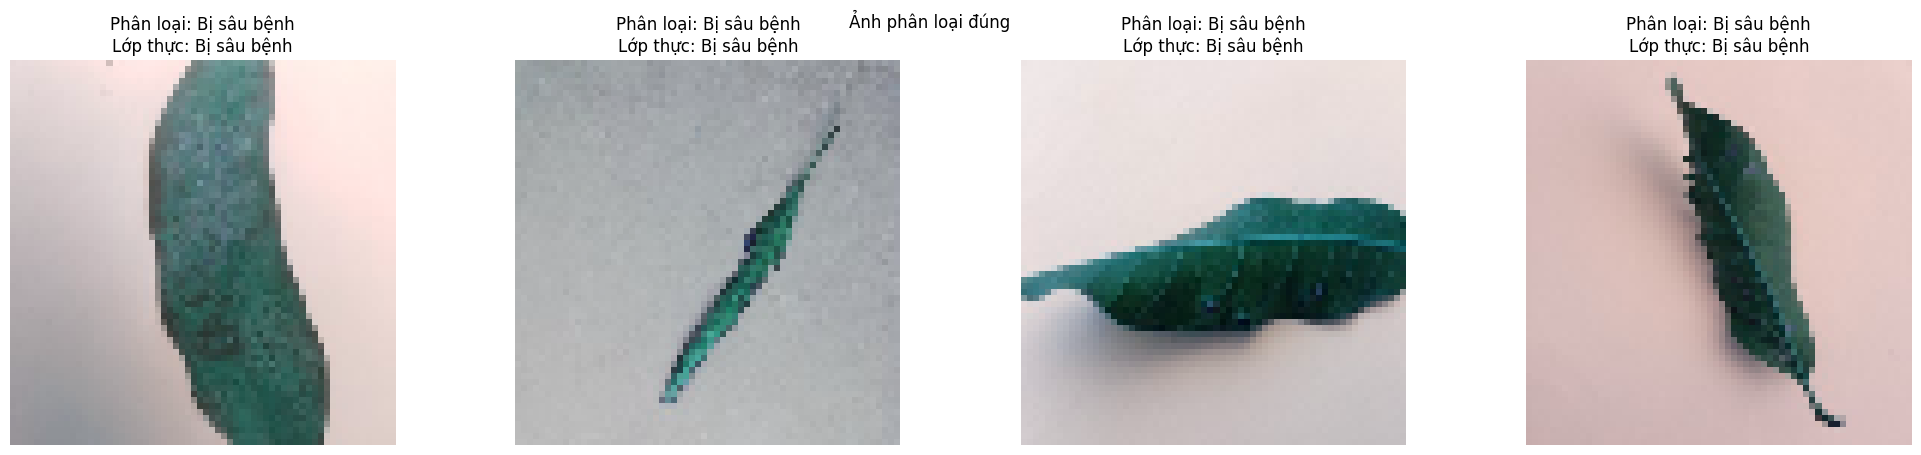

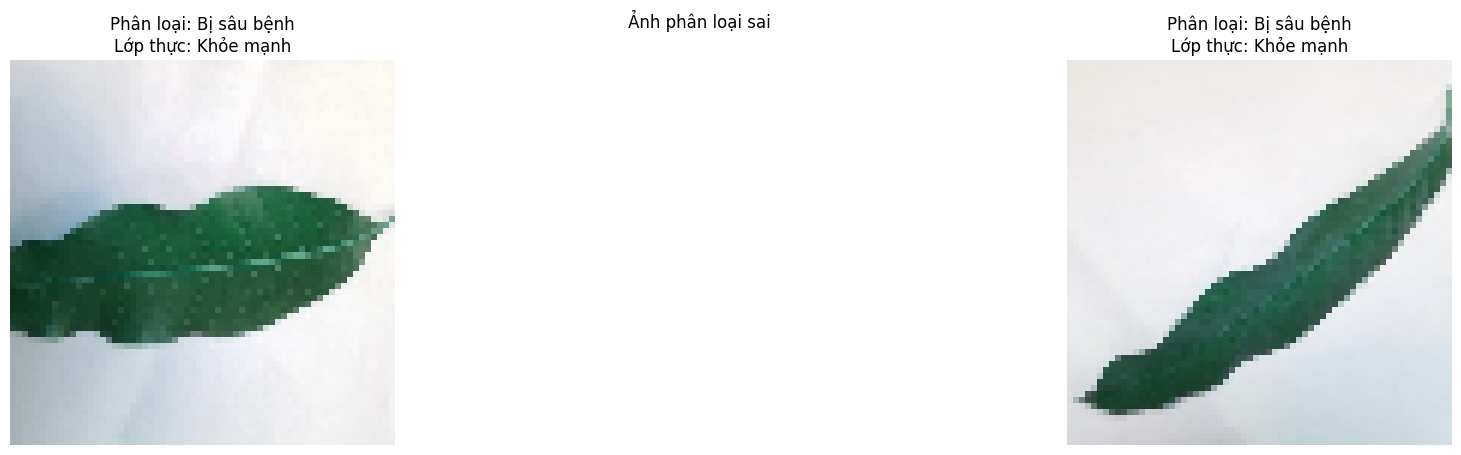

['sob_svc.pkl']

In [ ]:
param_grid = {'C' : np.arange(0.1,5,0.1) , 'kernel' : ['rbf',"poly"]}
sob_svc = GridSearchCV(SVC(max_iter=100000),param_grid,cv=5,scoring = 'f1',verbose=2,n_jobs=-1)
sob_svc.fit(X_train,y_train)
print("Best Parameters:", sob_svc.best_params_)
y_pred = sob_svc.predict(X_test)
print("Test Accuracy Score:", accuracy_score(y_pred, y_test))
print("F1 Score (weighted):", f1_score(y_pred, y_test, average='weighted'))
print("Confusion Matrix:\n", confusion_matrix(y_pred, y_test))
plot_classification_results(data_test, y_test, y_pred)
joblib.dump(sob_svc, 'sob_svc.pkl')

#Trích xuất đặc trưng bằng Histogram

In [ ]:
def feature_histogram(img) :
  hist = cv2.calcHist([img],[0,1,2],None,[8,8,8],[0,256,0,256,0,256])
  hist = hist/hist.max()
  return hist.flatten()

####Visualizing hình ảnh sau khi trích xuất đặc trưng Histogram

Khỏe mạnh


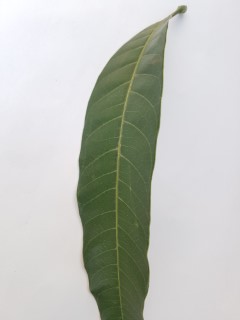

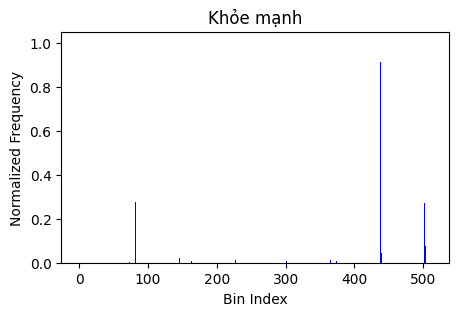

Nấm mốc bột


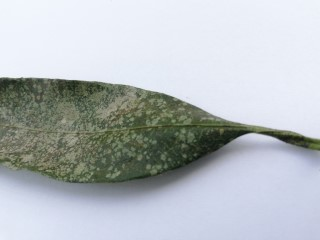

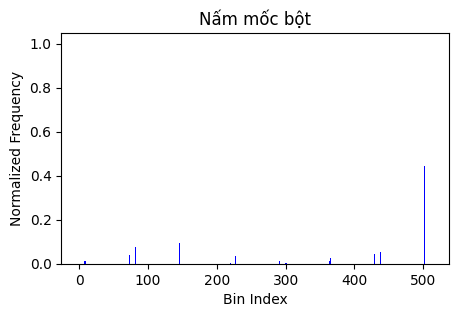

Nấm đen


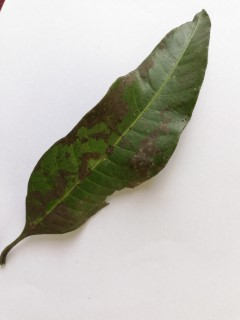

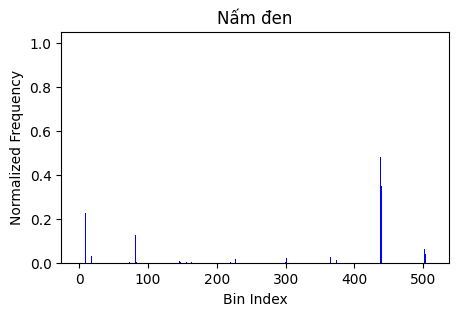

Vết loét


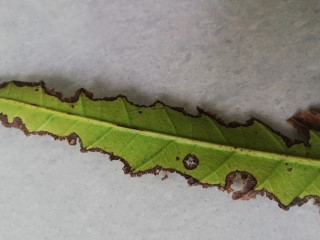

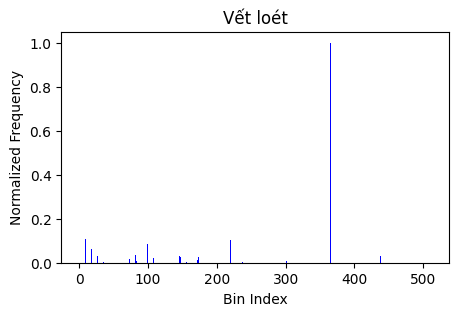

Ruồi cuốn lá


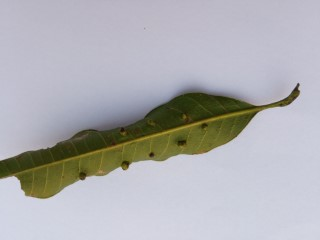

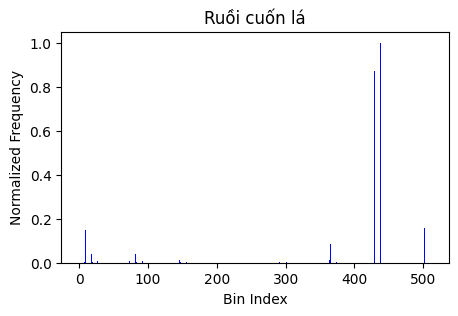

In [ ]:
for idx,category in enumerate(categories):
  print(f"{category}")
  class_dir = os.path.join(input_dir,category)
  for img_name in os.listdir(class_dir):
    img_dir = os.path.join(class_dir,img_name)
    img = cv2.imread(img_dir)
    cv2_imshow(img)
    img = cv2.resize(img,(64,64))
    hist = feature_histogram(img)
    break
  plt.figure(figsize=(5, 3))
  plt.bar(range(len(hist)), hist, color='blue')
  plt.title(f"{category}")
  plt.xlabel("Bin Index")
  plt.ylabel("Normalized Frequency")
  plt.show()

#### Trích xuất đặc trưng và chia tập dữ liệu

In [ ]:
data_train,data_test,y_train,y_test = train_test_split(data,labels,test_size=0.3,random_state=28)
X_train = [feature_histogram(i) for i in data_train]
X_train = np.asarray(X_train)
X_test = [feature_histogram(i) for i in data_test]
X_test = np.asarray(X_test)

####KNN Model

Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best Hyperparameters: {'metric': 'euclidean', 'n_neighbors': 1, 'weights': 'uniform'}
Test Accuracy Score: 0.9733333333333334
F1 Score (weighted): 0.9735391071851627
Confusion Matrix:
 [[137   7]
 [ 13 593]]


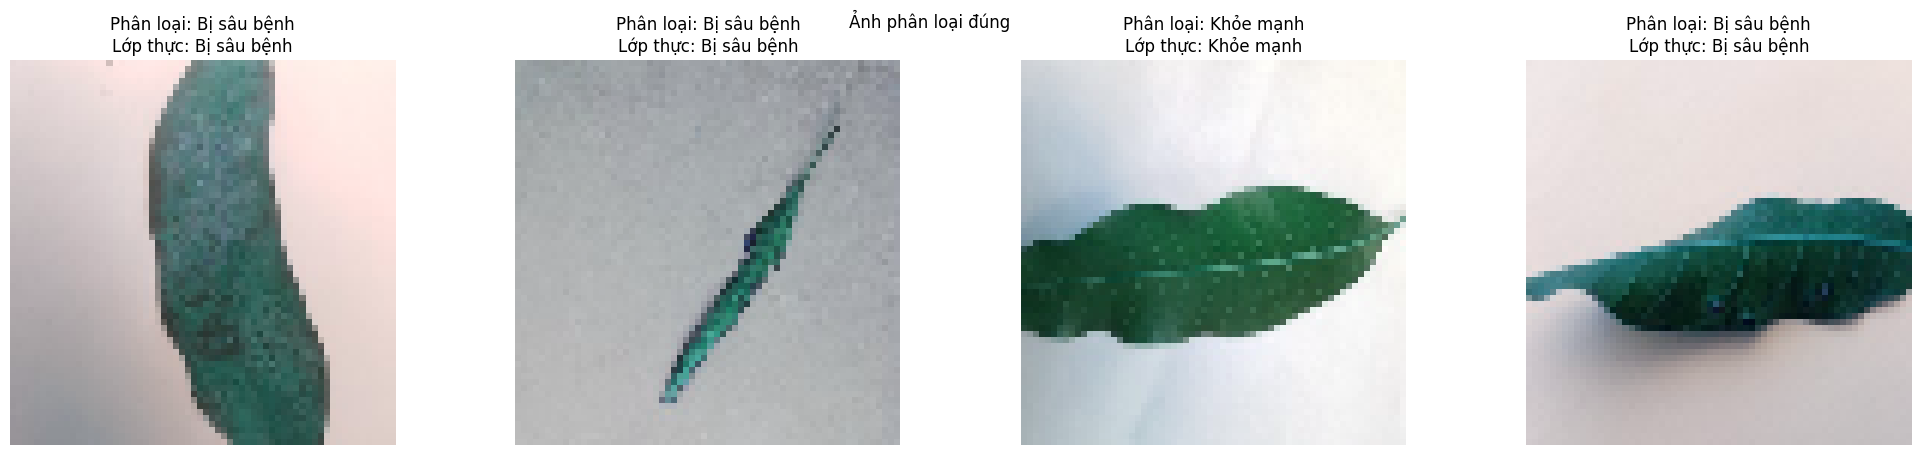

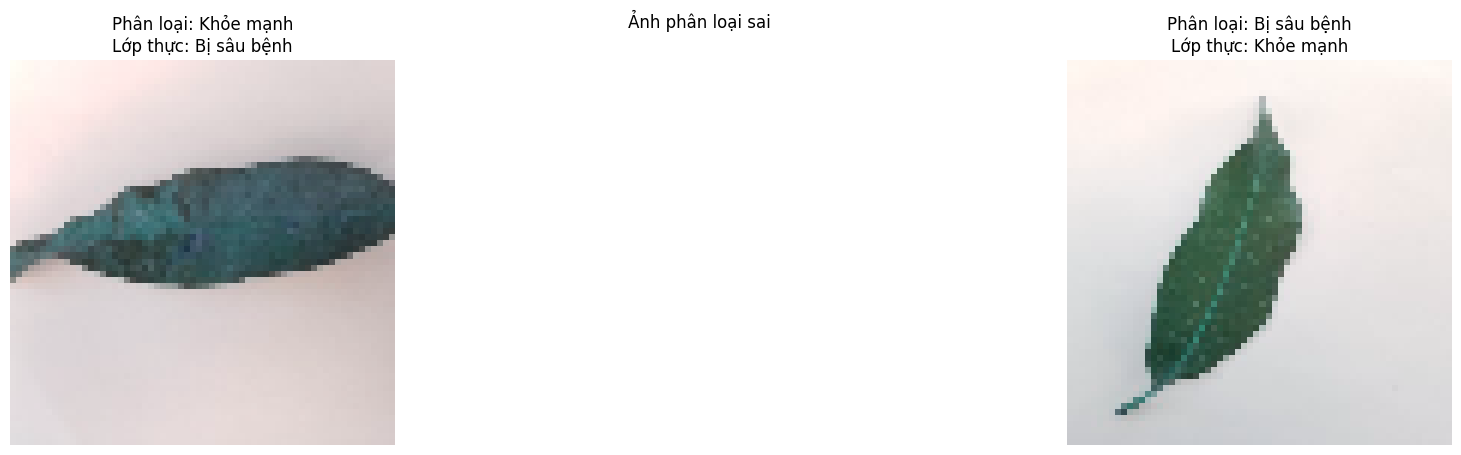

['his_knn.pkl']

In [ ]:
param_grid = {'n_neighbors' : np.arange(1,20,2), 'weights' : ['uniform','distance'], 'metric' : ['cosine','euclidean','minkowski']}
his_knn = GridSearchCV(KNeighborsClassifier(),param_grid,cv=5,scoring = 'f1',verbose=1)
his_knn.fit(X_train,y_train)
print("Best Hyperparameters:", his_knn.best_params_)
y_pred = his_knn.predict(X_test)
print("Test Accuracy Score:", accuracy_score(y_pred, y_test))
print("F1 Score (weighted):", f1_score(y_pred, y_test, average='weighted'))
print("Confusion Matrix:\n", confusion_matrix(y_pred, y_test))
#print("Classification Report:\n", classification_report(y_pred, y_test))
plot_classification_results(data_test, y_test, y_pred)
joblib.dump(his_knn, 'his_knn.pkl')

####SVC Model

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Hyperparameters: {'C': 1.9000000000000006, 'kernel': 'rbf'}
Test Accuracy Score: 0.9866666666666667
F1 Score (weighted): 0.9867695535925813
Confusion Matrix:
 [[142   2]
 [  8 598]]


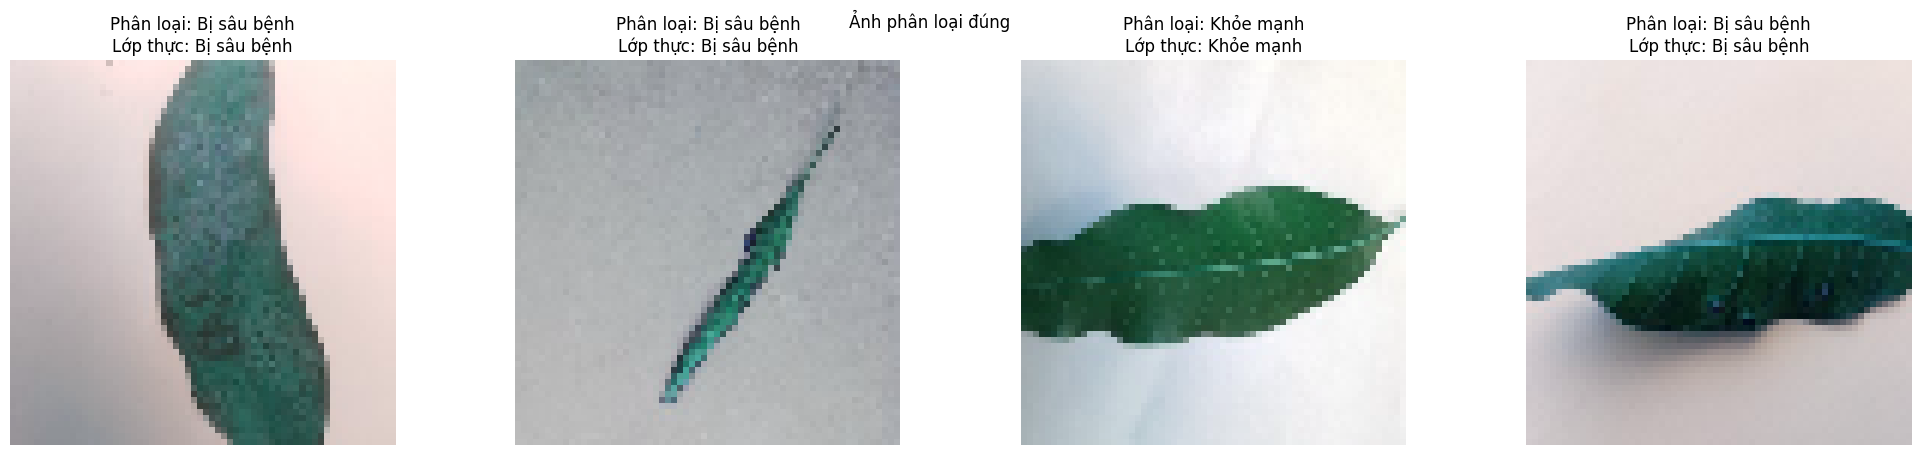

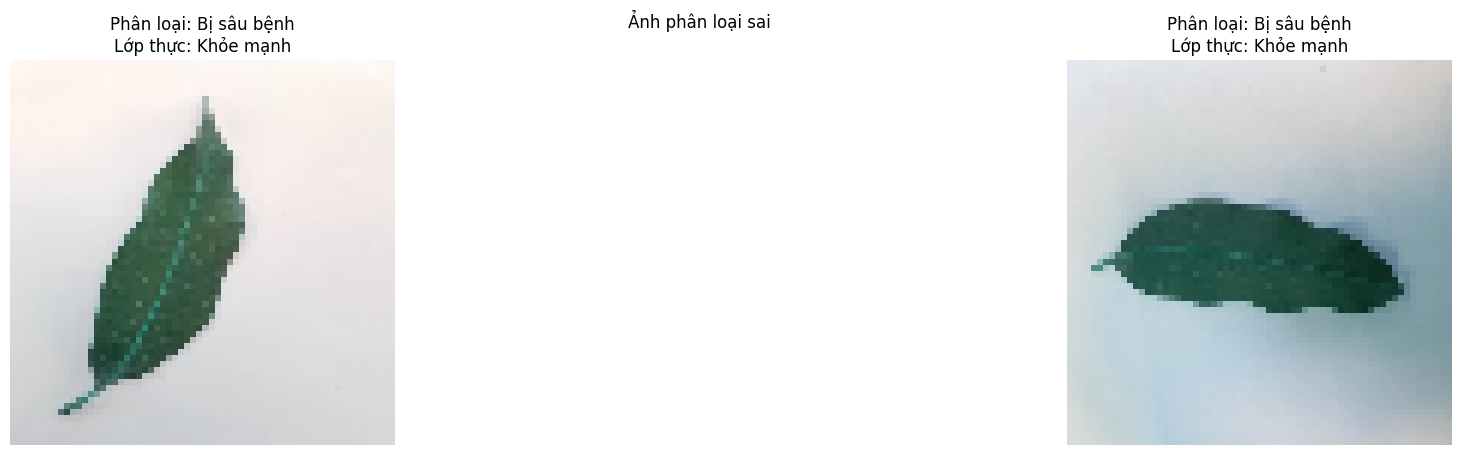

['his_svc.pkl']

In [ ]:
param_grid = {'C' : np.arange(0.2,2,0.1) , 'kernel' : ['linear','rbf']}
his_svc = GridSearchCV(SVC(max_iter = 10000),param_grid,cv=5,scoring = 'f1',verbose=1,n_jobs=-1)
his_svc.fit(X_train,y_train)
print("Best Hyperparameters:", his_svc.best_params_)
y_pred = his_svc.predict(X_test)
print("Test Accuracy Score:", accuracy_score(y_pred, y_test))
print("F1 Score (weighted):", f1_score(y_pred, y_test, average='weighted'))
print("Confusion Matrix:\n", confusion_matrix(y_pred, y_test))
plot_classification_results(data_test, y_test, y_pred)
joblib.dump(his_svc, 'his_svc.pkl')

# Phụ lục

In [ ]:
X = []
for i in data:
    sobel_features = feature_sobel(i)
    histogram_features = feature_histogram(i)
    combined_features = np.hstack((sobel_features, histogram_features))
    X.append(combined_features)
X = np.asarray(X)
X_train,X_test,y_train,y_test = train_test_split(X,labels,test_size=0.2,random_state=28)

####KNN Model

Best Parameters: {'n_neighbors': 5, 'weights': 'distance'}
Test Accuracy Score: 0.816
F1 Score (weighted): 0.8291112637362638
Confusion Matrix:
 [[ 38  31]
 [ 61 370]]


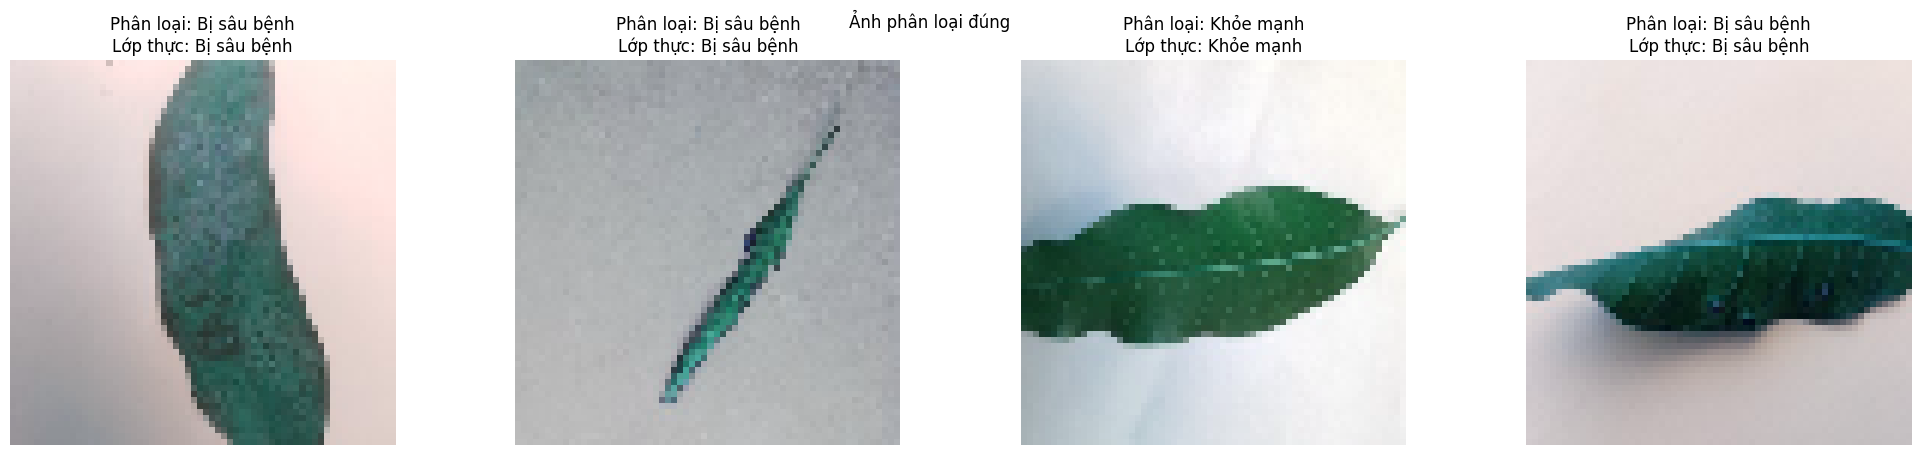

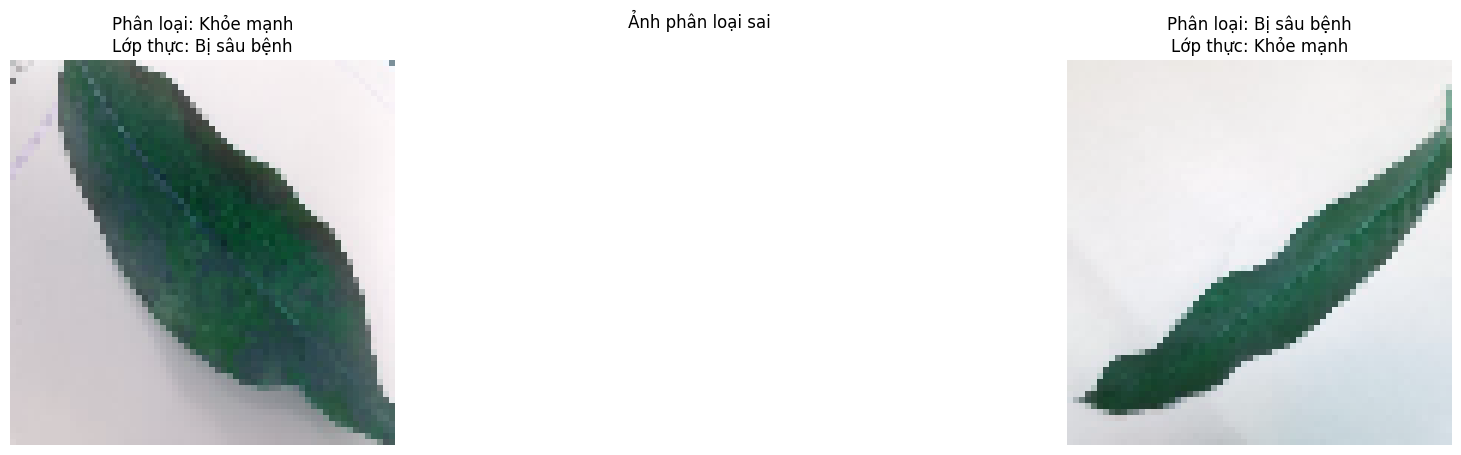

In [ ]:
grid_param = {'n_neighbors' : np.arange(1,30,1),'weights' : ['uniform','distance'] }
grid = GridSearchCV(KNeighborsClassifier(),grid_param,cv=5,scoring='accuracy')
grid.fit(X_train,y_train)
print("Best Parameters:", grid.best_params_)
y_pred = grid.predict(X_test)
print("Test Accuracy Score:", accuracy_score(y_pred, y_test))
print("F1 Score (weighted):", f1_score(y_pred, y_test, average='weighted'))
print("Confusion Matrix:\n", confusion_matrix(y_pred, y_test))
plot_classification_results(data_test, y_test, y_pred)

####SVC Model

Test Accuracy Score: 0.846
F1 Score (weighted): 0.8634429471273144
Confusion Matrix:
 [[ 39  17]
 [ 60 384]]


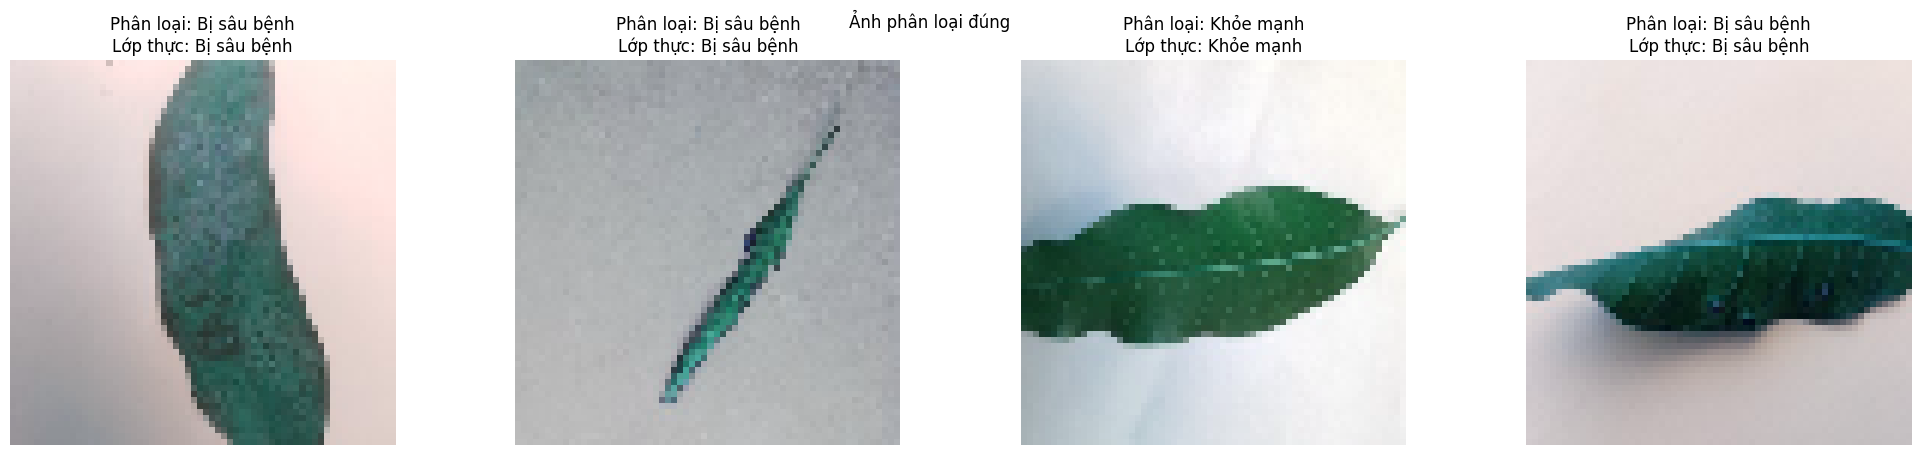

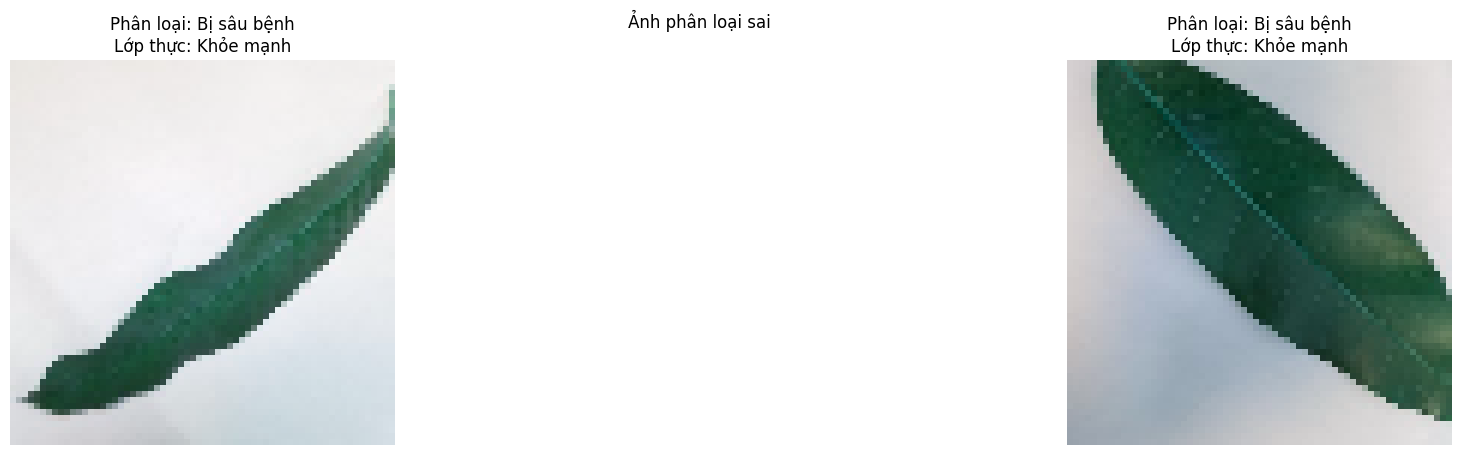

In [ ]:
grid = SVC(C = 10, gamma= 'scale', kernel = 'rbf')
grid.fit(X_train, y_train)
y_pred = grid.predict(X_test)
print("Test Accuracy Score:", accuracy_score(y_pred, y_test))
print("F1 Score (weighted):", f1_score(y_pred, y_test, average='weighted'))
print("Confusion Matrix:\n", confusion_matrix(y_pred, y_test))
plot_classification_results(data_test, y_test, y_pred)

#Thực nghiệm

In [ ]:
input_dir = "/content/MangoLeaf/evaluation"
categories = ['Khỏe mạnh','Bị sâu bệnh']

data = []
labels = []
datas = []
labelss = []
for idx,category in enumerate(categories):
  print(f"Loading image from category: {category}")
  if category != 'Khỏe mạnh' :
    idx = 1
  class_dir = os.path.join(input_dir,category)
  for img_name in os.listdir(class_dir) :
    img_dir = os.path.join(class_dir,img_name)
    img = cv2.imread(img_dir)
    datas.append(img)
    labelss.append(idx)
    img = cv2.resize(img,(64,64))
    data.append(img)
    labels.append(idx)
data = np.asarray(data)
labels = np.asarray(labels)

Loading image from category: Khỏe mạnh
Loading image from category: Bị sâu bệnh


In [ ]:
X_eval = [feature_histogram(i) for i in data]
X_eval = np.asarray(X_eval)


In [ ]:
def plot_classification_evaluation(data_test, y_test, y_pred, images=None):
    correct_indices = np.where(y_pred == y_test)[0]
    incorrect_indices = np.where(y_pred != y_test)[0]

    display_images(data_test, y_test, y_pred,correct_indices, "Ảnh phân loại đúng", 8)
    display_images(data_test, y_test, y_pred,incorrect_indices, "Ảnh phân loại sai", 8)

Test Accuracy Score: 1.0
F1 Score (weighted): 1.0
Confusion Matrix:
 [[5 0]
 [0 4]]


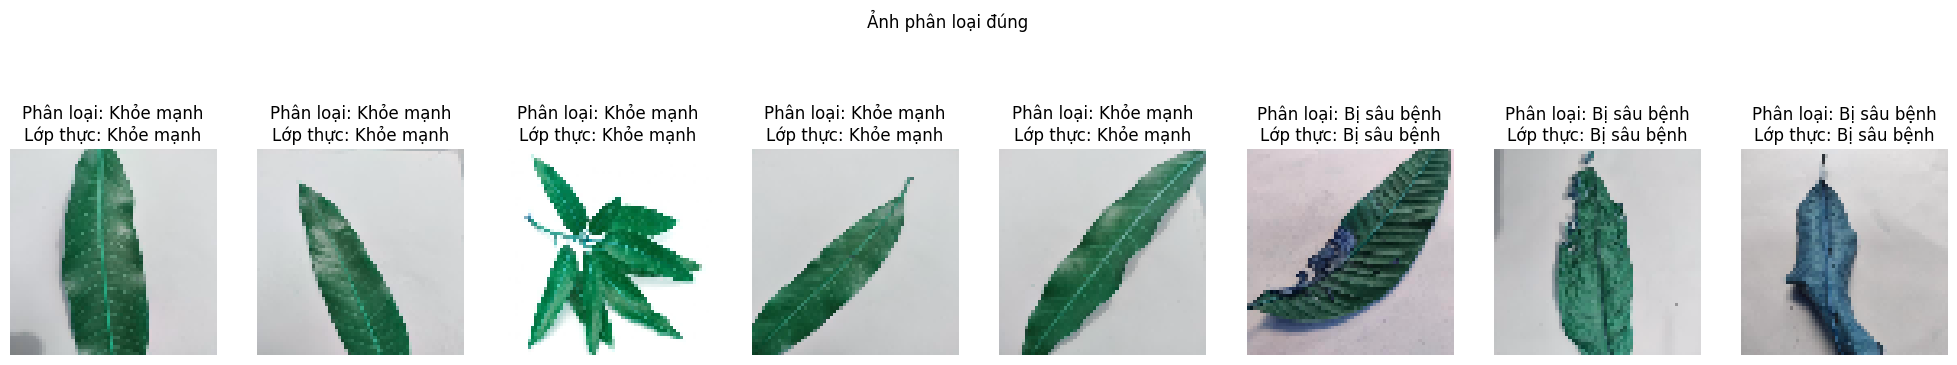

<Figure size 2500x500 with 0 Axes>

In [ ]:
his_svc = joblib.load('MangoLeaf/his_svc.pkl')
y_eval = his_svc.predict(X_eval)
print("Test Accuracy Score:", accuracy_score(y_eval, labels))
print("F1 Score (weighted):", f1_score(y_eval, labels, average='weighted'))
print("Confusion Matrix:\n", confusion_matrix(y_eval, labels))
plot_classification_evaluation(data, y_eval, labels)